<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL2_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements a deep learning pipeline for a text dataset (20 Newsgroups). To run this notebook, do the following:
1. First click the Colab `Run all` button. Due to some library conflicts you will need to restart session in the first cell below.
2. After that click `Run all` again (library installation and dataset loading are automated).
3. Select the confiuration you want in the last cell (default: fine tuning DistilBERT model).
4. After that click `Run Pipeline` in the last cell. The pipeline will run according to your configuration.

If you want to rerun the pipeline with another configuration, you need to rerun the last cell and then repeat from step 3.

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [1]:
# Require SESSION RESTART for first time running
%pip install gensim
# After restarting, press Run all again

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.0 MB/s eta 0:00:00


In [2]:
# Verify required libraries
import sys
import subprocess

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)

pip_install(["scikit-learn", "pandas", "tqdm", "matplotlib", "seaborn", "plotly", "wget",
             "WordCloud", "transformers", "datasets", "sentencepiece", "tokenizers", "torchtext"])

# Import libraries
import wget
import os, random, math, time, json
from tqdm import tqdm
from pprint import pprint
from collections import Counter
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, precision_recall_fscore_support, confusion_matrix
import torch
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn

import ipywidgets as widgets
from IPython.display import display, clear_output

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding


# Ensure reproducibility
RND = 42
random.seed(RND); np.random.seed(RND); torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 1.2.&nbsp;Download and store the dataset

In [3]:
url = "http://qwone.com/~jason/20Newsgroups/20news-18828.tar.gz"
filename = "20news-18828.tar.gz"
folder = "20news-18828"

if not os.path.exists(folder):
    if not os.path.exists(filename):
        print("Downloading file .tar.gz...")
        !wget -q {url} -O {filename}
        print("Done!")
    else:
        print("File .tar.gz already exists.")

    print("Extracting")
    !tar -xzf {filename}
    print("Done!")
else:
    print("Dataset already exists.")

# Load dataset
dataset = load_files("20news-18828", encoding="latin1")

print("\nNumber of documents:", len(dataset.data))
print("Number of classes:", len(dataset.target_names))

Done!
Extracting
Done!

Number of documents: 18828
Number of classes: 20


In [4]:
import re
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|[\w\.-]+@[\w\.-]+|\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

dataset_cleaned = [clean_text(doc) for doc in dataset.data]

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 2.&nbsp;Exploratory Data Analysis (EDA)

In [5]:
# Print the first 3 documents
for i in range(3):
    print(f"Document {i+1}")
    print("Target:", dataset.target_names[dataset.target[i]])
    print(dataset.data[i])

Document 1
Target: comp.graphics
From: haston@utkvx.utk.edu (Haston, Donald Wayne)
Subject: Church related graphics

I am looking for some good quality graphics files which are
suitable for use in church-related presentations. I prefer vector,
but anything would be helpful.

If you know of bulletin boards which have collections of this nature, or
commercial products, please inform me by email:

HASTON@UTKVX.UTK.EDU

Wayne Haston




Document 2
Target: comp.graphics
From: jr0930@eve.albany.edu (REGAN JAMES P)
Subject: Re: Pascal-Fractals

Apparently, my editor didn't do what I wanted it to do, so I'll try again.

i'm looking for any programs or code to do simple animation and/or
drawing using fractals in TurboPascal for an IBM
              Thanks in advance
-- 
 |||||||||||   		 	   ||||||||||| 
_|||||||||||_______________________|||||||||||_      jr0930@eve.albany.edu
-|||||||||||-----------------------|||||||||||-     jr0930@Albnyvms.bitnet
 |||||||||||  GO HEAVY OR GO HOME  ||||||||

Value counts for target:
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             994
rec.sport.baseball          994
sci.crypt                   991
sci.med                     990
rec.autos                   990
sci.space                   987
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
sci.electronics             981
comp.windows.x              980
comp.graphics               973
misc.forsale                972
comp.sys.mac.hardware       961
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


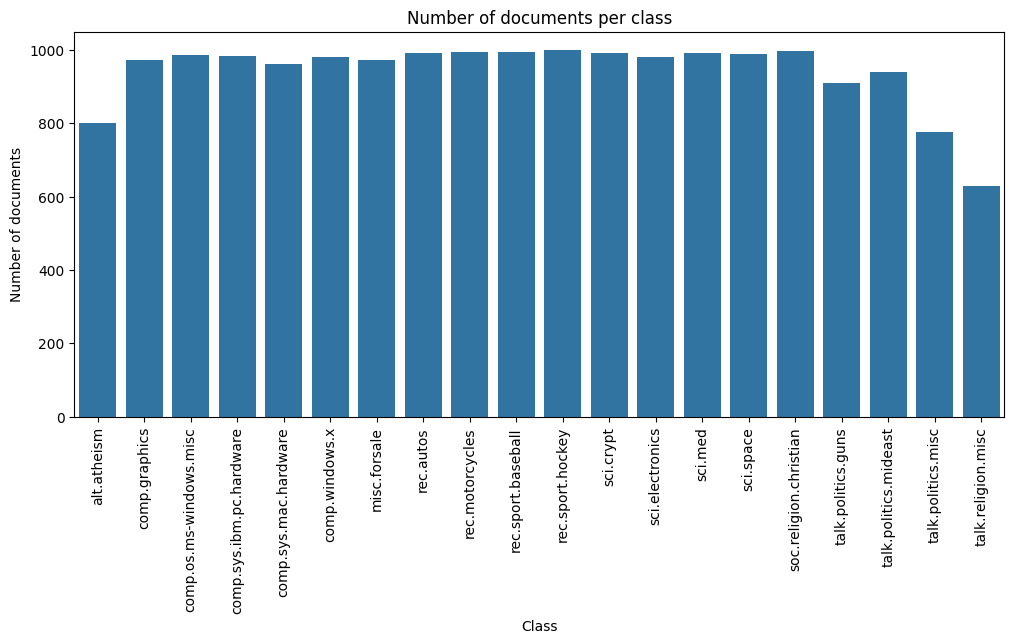

In [6]:
# Value counts for target
target_series = pd.Series(dataset.target)
target_series_named = target_series.map(lambda x: dataset.target_names[x])

print("Value counts for target:")
print(target_series_named.value_counts())

counts = Counter(dataset.target)

plt.figure(figsize=(12,5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.xticks(range(len(dataset.target_names)), dataset.target_names, rotation=90)
plt.title("Number of documents per class")
plt.ylabel("Number of documents")
plt.xlabel("Class")
plt.show()

Average document length: 272.49479498619075
Median document length: 164.0
Maximum document length: 11795
Minimum document length: 5


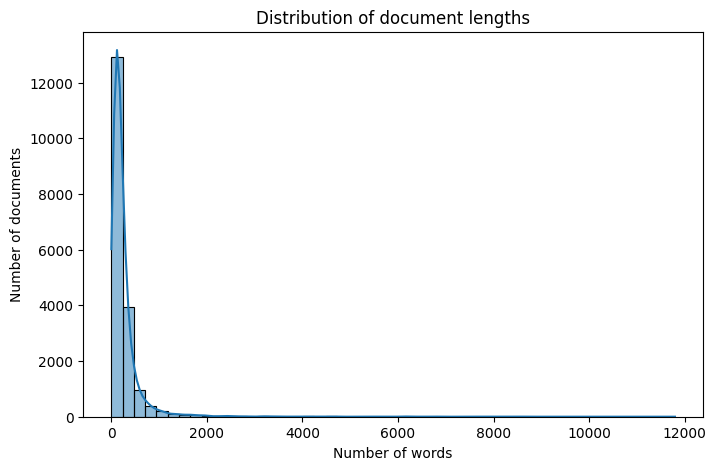

In [7]:
# Document lengths
doc_lengths = [len(doc.split()) for doc in dataset.data]

print("Average document length:", np.mean(doc_lengths))
print("Median document length:", np.median(doc_lengths))
print("Maximum document length:", np.max(doc_lengths))
print("Minimum document length:", np.min(doc_lengths))

plt.figure(figsize=(8,5))
sns.histplot(doc_lengths, bins=50, kde=True)
plt.title("Distribution of document lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.show()

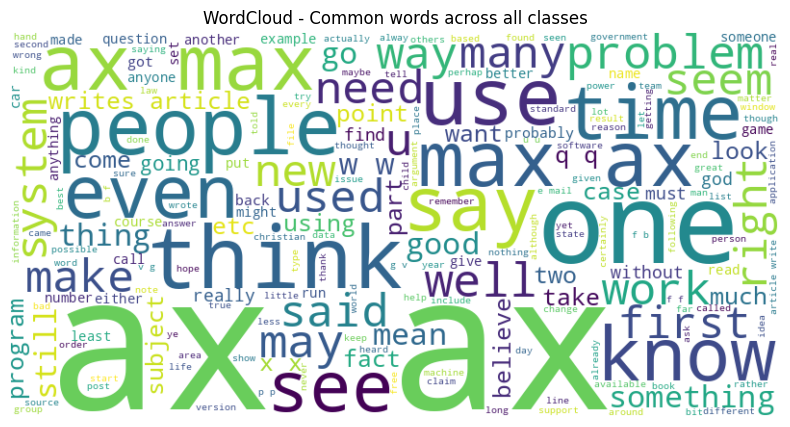

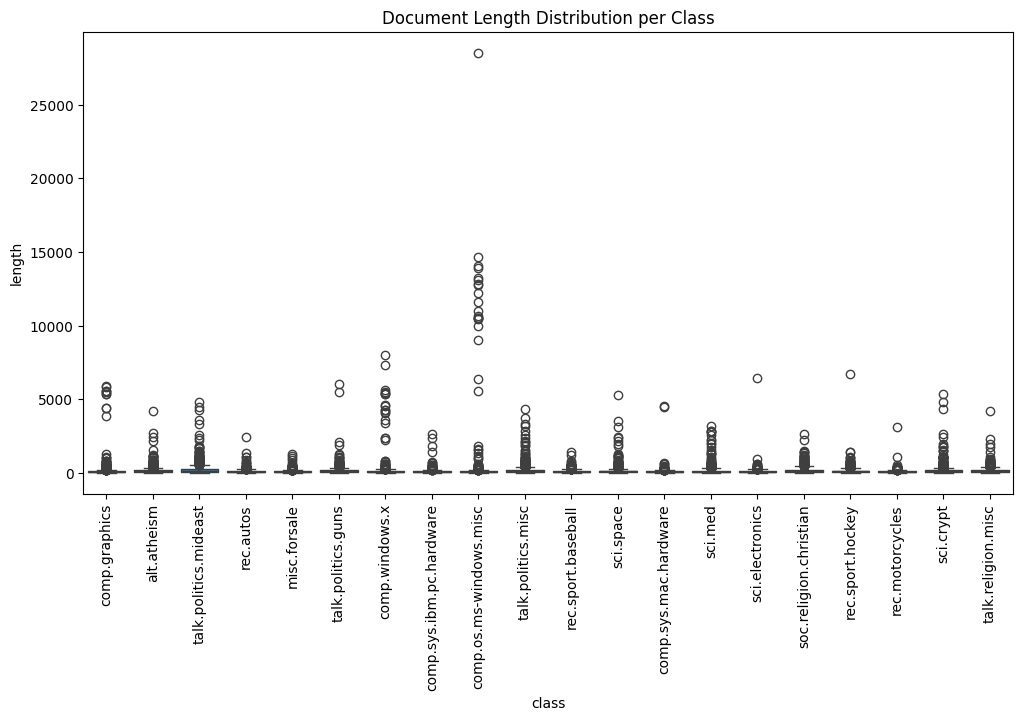

In [8]:
from wordcloud import WordCloud

text_all = " ".join(dataset_cleaned)
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(text_all)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Common words across all classes")
plt.show()

doc_lengths = [len(doc.split()) for doc in dataset_cleaned]
df_length = pd.DataFrame({"length": doc_lengths, "class": [dataset.target_names[i] for i in dataset.target]})
plt.figure(figsize=(12, 6))
sns.boxplot(x="class", y="length", data=df_length)
plt.xticks(rotation=90)
plt.title("Document Length Distribution per Class")
plt.show()

Vocabulary size (including stopwords): 170781


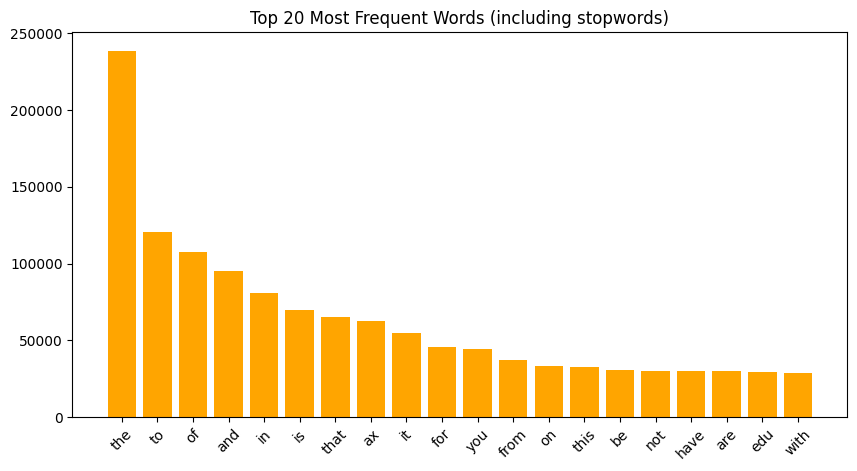

Vocabulary size (stopwords removed): 170470


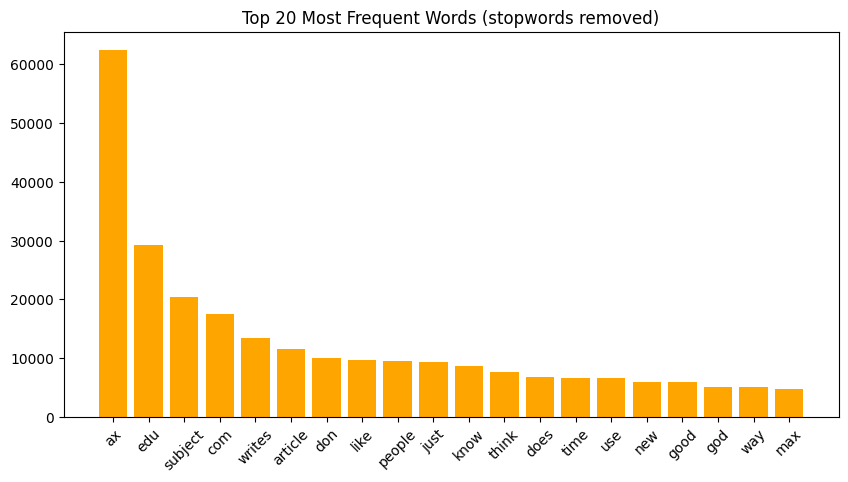

In [9]:
# Plot top 10 words and vocabulary size (including stopwords)
vectorizer = CountVectorizer(stop_words=None)
X = vectorizer.fit_transform(dataset.data)

word_counts = np.asarray(X.sum(axis=0)).ravel()
top_indices = word_counts.argsort()[::-1][:20]

vocab_1 = vectorizer.get_feature_names_out()
print(f"Vocabulary size (including stopwords): {len(vocab_1)}")

plt.figure(figsize=(10,5))
plt.bar([vocab_1[i] for i in top_indices], word_counts[top_indices], color='orange')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (including stopwords)")
plt.show()

# Plot top 10 words and vocabulary size (stopwords removed)
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(dataset.data)

word_counts = np.asarray(X.sum(axis=0)).ravel()
top_indices = word_counts.argsort()[::-1][:20]

vocab_2 = vectorizer.get_feature_names_out()
print(f"Vocabulary size (stopwords removed): {len(vocab_2)}")

plt.figure(figsize=(10,5))
plt.bar([vocab_2[i] for i in top_indices], word_counts[top_indices], color='orange')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (stopwords removed)")
plt.show()

# 3.&nbsp;Feature Extraction with Text Preprocessing

## 3.1.&nbsp;Train/Val/Test split with stratification

In [5]:
# Split dataset into train/val/test sets
X = dataset.data
# X = dataset_cleaned
y = dataset.target

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RND, stratify=dataset.target)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RND, stratify=y_temp)

print('Original dataset shape:', len(dataset.data))
print('Split -> Train:', len(X_train), '   Validation:', len(X_val), '   Test:', len(X_test))

Original dataset shape: 18828
Split -> Train: 13179    Validation: 2824    Test: 2825


## 3.2.&nbsp;Set up Tokenizer and Vectorizer
Depending on the UI selection, we will use whitespace tokenization + static embeddings (GloVe/Word2Vec) or transformer tokenizers + contextual embeddings.

For transformer embeddings, we use the same model as tokenizer to preserve meaning.

In [6]:
def get_tokenizer(config):
    name = config['tokenizer']
    if name == 'whitespace':
        return None
    elif name == 'bert':
        return AutoTokenizer.from_pretrained('bert-base-uncased')
    elif name == 'roberta':
        return AutoTokenizer.from_pretrained('roberta-base')
    else:
        return AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Static embedding loader (gensim downloader) - used for 'glove' or 'word2vec'
def load_static_embedding(vectorizer, embed_dim=300):
    import gensim.downloader as api
    if vectorizer == 'glove':
        if embed_dim == 300:
            name = 'glove-wiki-gigaword-300'
        elif embed_dim == 100:
            name = 'glove-wiki-gigaword-100'
        else:
            name = 'glove-wiki-gigaword-300'
    elif vectorizer == 'word2vec':
        if embed_dim == 300:
            name = 'word2vec-google-news-300'
        else:
            name = 'glove-twitter-200'
    else:
        raise ValueError('Unknown static vectorizer: ' + vectorizer)
    print('Loading embedding:', name)
    model = api.load(name)
    return model

def build_embedding_matrix(embedding_model, word2idx, embed_dim):
    vocab_size = len(word2idx)
    matrix = np.random.normal(scale=0.01, size=(vocab_size, embed_dim)).astype(np.float32)
    for w, idx in word2idx.items():
        if w in embedding_model:
            matrix[idx] = embedding_model[w]
    matrix[0] = np.zeros((embed_dim,), dtype=np.float32)
    return matrix

## 3.3.&nbsp;Dataset and Dataloader
We provide a Dataset wrapper for whitespace tokenization (with static embeddings) and a transformer-based dataset (using tokenizer).

In [7]:
class TextDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, config, vocab=None, word2idx=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.config = config
        self.vocab = vocab
        self.word2idx = word2idx

    def __len__(self): return len(self.texts)

    def whitespace_tokenize(self, text):
        return text.lower().split()

    def encode_whitespace(self, text):
        tokens = self.whitespace_tokenize(text)[:self.config['max_length']]
        ids = [self.word2idx.get(t, self.word2idx.get('<unk>')) for t in tokens]
        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = int(self.labels[idx])
        if self.config['tokenizer']=='whitespace':
            return self.encode_whitespace(text), label, text
        else:
            enc = self.tokenizer(text, truncation=True, padding=False, max_length=self.config['max_length'], return_tensors=None)
            return enc, label, text

def collate_whitespace(batch):
    ids = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    ids_padded = pad_sequence(ids, batch_first=True, padding_value=0)
    lengths = torch.tensor([len(x) for x in ids], dtype=torch.long)
    return ids_padded, lengths, labels

def collate_transformer(batch, tokenizer, config):
    texts = [item[2] for item in batch]
    labels = [item[1] for item in batch]
    out = tokenizer(texts, truncation=True, padding='longest', max_length=config['max_length'], return_tensors='pt')
    out['labels'] = torch.tensor(labels, dtype=torch.long)
    return out

# 4.&nbsp;Model Definition
We include a TextCNN, an LSTM classifier and a Hybrid option for static embeddings and use Hugging Face AutoModelForSequenceClassification for transformer fine-tuning.

## 4.1.&nbsp;TextCNN classifier
Kim 2014 style, from Kim, Y. (2014) Convolutional Neural Networks for Sentence Classification.

In [8]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, num_filters=100, kernel_sizes=(3,4,5), dropout=0.5, embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
            if freeze_embeddings:
                self.embedding.weight.requires_grad = False
        self.kernel_sizes = list(kernel_sizes)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k, padding=(k-1)//2)
            for k in self.kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(self.kernel_sizes), num_classes)

    def forward(self, input_ids, lengths=None):
        # input_ids: (batch, seq_len)
        emb = self.embedding(input_ids)                      # (batch, seq_len, embed_dim)
        emb_t = emb.transpose(1, 2)                          # (batch, embed_dim, seq_len) for Conv1d
        conv_outs = []
        for conv in self.convs:
            c = conv(emb_t)                                  # (batch, num_filters, seq_len)
            c = torch.relu(c)
            # max-over-time pooling (over seq_len)
            c_pool = torch.max(c, dim=2)[0]                 # (batch, num_filters)
            conv_outs.append(c_pool)
        cat = torch.cat(conv_outs, dim=1)                   # (batch, num_filters * n_kernels)
        out = self.dropout(cat)
        logits = self.fc(out)
        return logits

## 4.2.&nbsp;BiLSTM classifier

In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=1, bidirectional=True, dropout=0.3, embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
            if freeze_embeddings:
                self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=bidirectional, dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes)

    def forward(self, input_ids, lengths=None):
        x = self.embedding(input_ids)
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h, _) = self.lstm(packed)
        else:
            _, (h, _) = self.lstm(x)
        if self.lstm.bidirectional:
            h_cat = torch.cat([h[-2], h[-1]], dim=1)
        else:
            h_cat = h[-1]
        out = self.dropout(h_cat)
        return self.fc(out)

## 4.3.&nbsp;Hybrid CNN+BiLSTM classifier
Hybrid: CNN (local feature extractor) -> LSTM (sequence modeling)

In [10]:
class HybridCNNLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=1, bidirectional=True, dropout=0.3,
                 num_filters=100, kernel_sizes=(3,4,5),
                 embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
            if freeze_embeddings:
                self.embedding.weight.requires_grad = False

        self.kernel_sizes = list(kernel_sizes)
        # Convs produce features per position (padding keeps seq_len)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k, padding="same")
            for k in self.kernel_sizes
        ])
        self.total_filters = num_filters * len(self.kernel_sizes)

        # LSTM expects input_size = total_filters
        self.lstm = nn.LSTM(self.total_filters, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes)

    def forward(self, input_ids, lengths=None):
        # Embedding
        emb = self.embedding(input_ids)                      # (batch, seq_len, embed_dim)
        emb_t = emb.transpose(1, 2)                          # (batch, embed_dim, seq_len)
        conv_feats = []
        for conv in self.convs:
            c = conv(emb_t)                                  # (batch, num_filters, seq_len)
            c = torch.relu(c)
            c = c.transpose(1, 2)                           # -> (batch, seq_len, num_filters)
            conv_feats.append(c)
        # concat along feature dim to get per-position features
        feat = torch.cat(conv_feats, dim=2)                  # (batch, seq_len, total_filters)

        # pack & LSTM
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(feat, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h, _) = self.lstm(packed)
        else:
            _, (h, _) = self.lstm(feat)

        # get last hidden
        if self.lstm.bidirectional:
            h_cat = torch.cat([h[-2], h[-1]], dim=1)
        else:
            h_cat = h[-1]
        out = self.dropout(h_cat)
        return self.fc(out)

## 4.4.&nbsp;Hugging Face Transformer
Define later when use in training

# 5.&nbsp;Training and Evaluation
Training loops include tqdm progress bars. We log epoch-level metrics (loss, accuracy) and collect them for visualization.

## 5.1.&nbsp;For CNN/LSTM
Cross Entropy for loss and Adam optimizer

In [11]:
def train_nn(model, train_loader, val_loader, config, target_names, device):
    model.to(device)
    model_type = config['model_type']
    patience = config['patience']
    patience_counter = 0
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{config["epochs"]}', unit='batch')
        for batch in pbar:
            input_ids, lengths, labels = batch
            input_ids = input_ids.to(device); lengths = lengths.to(device); labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        train_loss = total_loss / len(train_loader)
        val_metrics, val_loss = evaluate_nn(model, val_loader, target_names, device, return_loss=True)
        val_acc = val_metrics['accuracy']
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
        print(f'Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')
        improved = False
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            improved = True
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            improved = True
        if improved:
            patience_counter = 0
            torch.save(model.state_dict(), f"best_{config['model_type']}.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    return history

def evaluate_nn(model, data_loader, target_names, device, return_loss=False):
    model.eval()
    preds = []; truths = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating', unit='batch'):
            input_ids, lengths, labels = batch
            input_ids = input_ids.to(device); lengths = lengths.to(device); labels = labels.to(device)
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            batch_preds = logits.argmax(dim=1).cpu().numpy().tolist()
            preds.extend(batch_preds); truths.extend(labels.cpu().numpy().tolist())

    acc = accuracy_score(truths, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(truths, preds, average='weighted', zero_division=0)
    metrics = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

    if return_loss:
        return metrics, total_loss / len(data_loader)
    else:
        report = classification_report(truths, preds, zero_division=0, target_names=target_names)
        return metrics, report

## 5.2.&nbsp;For transformer fine-tuning
Train using Hugging Face Trainer

In [12]:
def transform_dataset_for_hf(texts, labels, tokenizer, config):
    enc = tokenizer(texts, truncation=True, padding=True, max_length=config['max_length'])
    ds = {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask'], 'labels': labels}
    import datasets as dslib
    return dslib.Dataset.from_dict(ds)

def train_transformer(train_texts, train_labels, val_texts, val_labels, tokenizer, config, target_names):
    model_name = config['tokenizer']
    if model_name == 'bert':
        model_name = 'bert-base-uncased'
    elif model_name == 'roberta':
        model_name = 'roberta-base'
    else:
        model_name = 'distilbert-base-uncased'
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(target_names))
    hf_train = transform_dataset_for_hf(train_texts, train_labels, tokenizer, config)
    hf_val = transform_dataset_for_hf(val_texts, val_labels, tokenizer, config)
    args = TrainingArguments(
        output_dir='hf_out',
        eval_strategy='epoch',
        save_strategy='epoch',
        learning_rate=config['lr'],
        warmup_steps=config['warmup_steps'],
        weight_decay=config['weight_decay'],
        per_device_train_batch_size=config['batch_size'],
        per_device_eval_batch_size=config['batch_size'],
        num_train_epochs=config['epochs'],
        load_best_model_at_end=True,
        metric_for_best_model='accuracy',
        logging_dir='hf_logs',
        logging_steps=10,
        report_to='none'
    )
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
        return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    trainer = Trainer(
        model=model, args=args, train_dataset=hf_train, eval_dataset=hf_val,
        processing_class=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics
    )
    trainer.train()
    return trainer

# 6.&nbsp;Visualization
We provide functions to show interactive loss/accuracy curves and a confusion matrix heatmap.

In [13]:
# Plotting helpers (Matplotlib)
def plot_metrics(history):
    epochs = list(range(1, len(history['train_loss'])+1))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history['train_loss'], marker='o', linestyle='-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], marker='o', linestyle='-', label='Val Loss')
    plt.title('Loss per epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history['val_acc'], marker='o', linestyle='-', label='Val Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 7.&nbsp;Main pipeline
Combine all the steps into one pipeline.

In [14]:
def main_pipeline(config, target_names, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, comparison_mode=False):
    # 1) Tokenizer & vectorizer preparation
    tokenizer = get_tokenizer(config)
    # For whitespace build vocab
    if config['tokenizer']=='whitespace':
        # build vocab from train_texts
        from collections import Counter
        counter = Counter()
        for t in tqdm(train_texts, desc='Building vocab'):
            counter.update(t.lower().split())
        vocab = ['<pad>','<unk>'] + [w for w,_ in counter.most_common(50000)]
        word2idx = {w:i for i,w in enumerate(vocab)}
    else:
        vocab, word2idx = None, None

    # static embeddings if needed
    embedding_model = None
    if config['vectorizer'] in ('glove','word2vec'):
        embedding_model = load_static_embedding(config['vectorizer'], embed_dim=config.get('embedding_dim',300))
        embedding_matrix = build_embedding_matrix(embedding_model, word2idx, config.get('embedding_dim',300))
    else:
        embedding_matrix = None

    # 2) Datasets and loaders
    if config['tokenizer']=='whitespace':
        train_dataset = TextDataset(train_texts, train_labels, tokenizer=None, config=config, vocab=vocab, word2idx=word2idx)
        val_dataset = TextDataset(val_texts, val_labels, tokenizer=None, config=config, vocab=vocab, word2idx=word2idx)
        test_dataset = TextDataset(test_texts, test_labels, tokenizer=None, config=config, vocab=vocab, word2idx=word2idx)
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, collate_fn=collate_whitespace, num_workers=config['num_workers'])
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=collate_whitespace, num_workers=config['num_workers'])
        test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=collate_whitespace, num_workers=config['num_workers'])
    else:
        train_dataset = TextDataset(train_texts, train_labels, tokenizer=tokenizer, config=config)
        val_dataset = TextDataset(val_texts, val_labels, tokenizer=tokenizer, config=config)
        test_dataset = TextDataset(test_texts, test_labels, tokenizer=tokenizer, config=config)
        def transformer_collate(batch): return collate_transformer(batch, tokenizer, config)
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, collate_fn=transformer_collate, num_workers=config['num_workers'])
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=transformer_collate, num_workers=config['num_workers'])
        test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=transformer_collate, num_workers=config['num_workers'])

    # 3) Model selection & training
    history = None
    final_metrics = {}
    if config['model_type'] == 'transformer_finetune':
        print(f"Running {config['model_type']} with tokenizer: {config.get('tokenizer')}")
        trainer = train_transformer(train_texts, train_labels, val_texts, val_labels, tokenizer, config, target_names)
        # evaluate on test
        hf_test = transform_dataset_for_hf(test_texts, test_labels, tokenizer, config)
        preds_output = trainer.predict(hf_test)
        preds = np.argmax(preds_output.predictions, axis=-1)
        acc = accuracy_score(test_labels, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(test_labels, preds, average='weighted', zero_division=0)
        final_metrics = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
        if not comparison_mode:
            print('\nTest accuracy:', acc)
            print('Weighted precision/recall/f1:', prec, rec, f1)
            plot_confusion_matrix(test_labels, preds, target_names)
    else:
        if config['model_type'] == 'cnn':
            model = TextCNN(vocab_size=len(word2idx),
                            embed_dim=config['embedding_dim'],
                            num_classes=len(target_names),
                            num_filters=config['num_filters'],
                            kernel_sizes=config['kernel_sizes'],
                            dropout=config['dropout'],
                            embedding_matrix=embedding_matrix,
                            freeze_embeddings=config['freeze'])
        elif config['model_type'] == 'lstm':
            model = LSTMClassifier(vocab_size=len(word2idx),
                                   embed_dim=config['embedding_dim'],
                                   hidden_dim=config['hidden_dim'],
                                   num_classes=len(target_names),
                                   num_layers=config['num_layers'],
                                   bidirectional=config['bidirectional'],
                                   dropout=config['dropout'],
                                   embedding_matrix=embedding_matrix,
                                   freeze_embeddings=config['freeze'])
        else: # Hybrid
            model = HybridCNNLSTM(vocab_size=len(word2idx),
                                  embed_dim=config['embedding_dim'],
                                  hidden_dim=config['hidden_dim'],
                                  num_classes=len(target_names),
                                  num_layers=config['num_layers'],
                                  bidirectional=config['bidirectional'],
                                  dropout=config['dropout'],
                                  num_filters=config['num_filters'],
                                  kernel_sizes=config['kernel_sizes'],
                                  embedding_matrix=embedding_matrix,
                                  freeze_embeddings=config.get('freeze_embeddings', False))
        if not comparison_mode:
            print(model)
        history = train_nn(model, train_loader, val_loader, config, target_names, device)
        # load best and evaluate
        model.load_state_dict(torch.load(f"best_{config['model_type']}.pt", map_location=device))
        test_metrics, test_report = evaluate_nn(model, test_loader, target_names, device)
        final_metrics = test_metrics
        if not comparison_mode:
            print('\nTest accuracy:', test_metrics['accuracy'])
            print(test_report)
            # For confusion matrix, produce preds
            preds = []
            truths = []
            model.eval()
            with torch.no_grad():
                for batch in tqdm(test_loader, desc='Predicting test set'):
                    input_ids, lengths, labels = batch
                    logits = model(input_ids.to(device), lengths.to(device))
                    preds.extend(logits.argmax(dim=1).cpu().numpy().tolist())
                    truths.extend(labels.numpy().tolist())
            plot_metrics(history)
            plot_confusion_matrix(truths, preds, target_names)

    # Save config and results
    if not comparison_mode:
        with open('config_used_ui.json','w') as f:
            json.dump(config, f, indent=2)
        print('\nSaved config_used_ui.json')

    return final_metrics, history

# 8.&nbsp;Run from config
Run your desired pipeline. However there are requirements:
- Static embeddings require whitespace tokenizer.
- CNN/LSTM model must use static embeddings (due to contextual embeddings making the CNN/LSTM layer obsolete).
- Transformer embeddings require transformer tokenizer (BERT/RoBERTa).
- Transformer fine-tuning requires the same tokenizer and vectorizer to preserve dimension and meaning.

Recommended hyperparameters:
| Model      | LR          | Weight Decay | Dropout | Epochs | Batch | Comments                 |
| ---------- | ----------- | ------------ | ------- | ------ | ----- | ------------------------ |
| TextCNN    | 1e-3        | 1e-4         | 0.5     | 10–15  | 64 | Fast, simple baseline    |
| BiLSTM     | 3e-4 – 1e-3 | 1e-5         | 0.3–0.5 | 10–20  | 32 | Good balance             |
| CNN+BiLSTM | 5e-4        | 1e-5         | 0.5     | 10–15  | 32 | Slightly heavier         |
| Tranformer fine-tune | 2e-5 – 5e-5 | 0.01         | 0.1 (Defined)     | 3–5    | 16 | SOTA contextual baseline |


In [16]:
# Tokenizer, vectorizer, model options (these map to internal names)
mode_widget = widgets.ToggleButtons(options=['Single Model', 'Comparison'], value='Single Model', description='Mode:')
tokenizer_widget = widgets.Dropdown(options=[('Whitespace','whitespace'), ('DistilBERT WordPiece','distilbert'), ('BERT WordPiece','bert'), ('RoBERTa BPE','roberta')],
                                    value='distilbert', description='Tokenizer:')

vectorizer_widget = widgets.Dropdown(options=[('GloVe','glove'), ('Word2Vec','word2vec'), ('Transformer (contextual)','transformer')],
                                    value='transformer', description='Vectorizer:')

model_widget = widgets.Dropdown(options=[('TextCNN','cnn'), ('LSTM','lstm'), ('Hybrid CNN+LSTM','hybrid'), ('Transformer fine-tune','transformer_finetune')],
                                value='transformer_finetune', description='Model:')

lr_widget = widgets.FloatLogSlider(value=5e-5, base=10, min=-6, max=-2, step=0.1, description='LR:')
decay_widget = widgets.FloatLogSlider(value=0.01, base=10, min=-5, max=-2, step=0.1, description='Decay:')
dropout_widget = widgets.FloatSlider(value=0.1, min=0.1, max=0.6, step=0.1, description='Dropout:')
epochs_widget = widgets.IntSlider(value=3, min=1, max=30, step=1, description='Epochs:')
batch_widget = widgets.IntSlider(value=16, min=4, max=128, step=4, description='Batch size:')
maxlen_widget = widgets.IntSlider(value=256, min=32, max=1024, step=32, description='Max seq len:')

hidden_dim_widget = widgets.IntSlider(value=256, min=32, max=512, step=32, description='Hidden dim:')
num_layers_widget = widgets.IntSlider(value=1, min=1, max=3, step=1, description='Num layers:')
bidirectional_widget = widgets.Checkbox(value=True, description='Bidirectional LSTM')

num_filters_widget = widgets.IntSlider(value=100, min=50, max=300, step=50, description='Num filters:')
kernel_sizes_widget = widgets.Text(value='3,4,5', description='Kernel sizes:')

run_button = widgets.Button(description='🚀 Run Pipeline', button_style='success')
output = widgets.Output()

def default_hparams():
    # Define base default hyperparameters
    base_hparams = {
        'cnn':        dict(tokenizer='whitespace', vectorizer='glove', lr=1e-3, weight_decay=1e-4, dropout=0.5, epochs=12, batch_size=64, kernel_sizes='3,4,5', embedding_dim=300, num_filters=100),
        'lstm':       dict(tokenizer='whitespace', vectorizer='glove', lr=3e-4, weight_decay=1e-5, dropout=0.4, epochs=15, batch_size=32, hidden_dim=256, num_layers=1, bidirectional=True, embedding_dim=300),
        'hybrid':     dict(tokenizer='whitespace', vectorizer='glove', lr=5e-4, weight_decay=1e-5, dropout=0.5, epochs=15, batch_size=32, kernel_sizes='3,5,7', hidden_dim=128, num_layers=1, bidirectional=True, embedding_dim=300, num_filters=100),
        'transformer_finetune': dict(tokenizer='distilbert', vectorizer='transformer', lr=5e-5, weight_decay=0.01, dropout=0.1, epochs=3, batch_size=16),
    }

    # Add common parameters to each default hparam set
    common_params = {
        'max_length': 256,
        'random_seed': 42,
        'num_workers': 2,
        'warmup_steps': 500,
        'patience': 3,
        'freeze': False,
        'embedding_dim': None, # Will be set to 300 for static embeddings if not explicitly defined
        'hidden_dim': None,
        'num_layers': None,
        'bidirectional': None,
        'num_filters': None,
        'kernel_sizes': None,
    }

    for model_key in base_hparams:
        for k, v in common_params.items():
            base_hparams[model_key].setdefault(k, v)

        # Specific overrides for embedding_dim
        if base_hparams[model_key]['vectorizer'] in ['glove', 'word2vec'] and base_hparams[model_key]['embedding_dim'] is None:
            base_hparams[model_key]['embedding_dim'] = 300

        # Convert kernel_sizes string to list if present
        if 'kernel_sizes' in base_hparams[model_key] and isinstance(base_hparams[model_key]['kernel_sizes'], str):
             base_hparams[model_key]['kernel_sizes'] = [int(k) for k in base_hparams[model_key]['kernel_sizes'].split(',')]

    return base_hparams


def update_ui(change=None):
    hparams = default_hparams()

    # List of all single-model specific control widgets
    single_model_widgets = [
        tokenizer_widget, vectorizer_widget, model_widget,
        lr_widget, decay_widget, dropout_widget, epochs_widget, batch_widget, maxlen_widget,
        hidden_dim_widget, num_layers_widget, bidirectional_widget,
        num_filters_widget, kernel_sizes_widget
    ]

    if mode_widget.value == 'Single Model':
        for w in single_model_widgets:
            w.layout.display = 'flex'
            w.disabled = False

        model_type = model_widget.value
        defaults = hparams[model_type]

        # Set values for common widgets from defaults
        lr_widget.value = defaults['lr']
        decay_widget.value = defaults['weight_decay']
        dropout_widget.value = defaults['dropout']
        epochs_widget.value = defaults['epochs']
        batch_widget.value = defaults['batch_size']
        maxlen_widget.value = defaults['max_length']
        tokenizer_widget.value = defaults['tokenizer']
        vectorizer_widget.value = defaults['vectorizer']

        # Hide all model-specific widgets first
        hidden_dim_widget.layout.display = 'none'; hidden_dim_widget.disabled = True
        num_layers_widget.layout.display = 'none'; num_layers_widget.disabled = True
        bidirectional_widget.layout.display = 'none'; bidirectional_widget.disabled = True
        num_filters_widget.layout.display = 'none'; num_filters_widget.disabled = True
        kernel_sizes_widget.layout.display = 'none'; kernel_sizes_widget.disabled = True

        # Show and set values for relevant model-specific widgets
        if model_type == 'cnn':
            kernel_sizes_widget.value = ','.join(map(str, defaults['kernel_sizes']))
            num_filters_widget.value = defaults['num_filters']
            num_filters_widget.layout.display = 'flex'; num_filters_widget.disabled = False
            kernel_sizes_widget.layout.display = 'flex'; kernel_sizes_widget.disabled = False
        elif model_type == 'lstm':
            hidden_dim_widget.value = defaults['hidden_dim']
            num_layers_widget.value = defaults['num_layers']
            bidirectional_widget.value = defaults['bidirectional']
            hidden_dim_widget.layout.display = 'flex'; hidden_dim_widget.disabled = False
            num_layers_widget.layout.display = 'flex'; num_layers_widget.disabled = False
            bidirectional_widget.layout.display = 'flex'; bidirectional_widget.disabled = False
        elif model_type == 'hybrid':
            hidden_dim_widget.value = defaults['hidden_dim']
            num_layers_widget.value = defaults['num_layers']
            kernel_sizes_widget.value = ','.join(map(str, defaults['kernel_sizes']))
            bidirectional_widget.value = defaults['bidirectional']
            num_filters_widget.value = defaults['num_filters']
            hidden_dim_widget.layout.display = 'flex'; hidden_dim_widget.disabled = False
            num_layers_widget.layout.display = 'flex'; num_layers_widget.disabled = False
            bidirectional_widget.layout.display = 'flex'; bidirectional_widget.disabled = False
            num_filters_widget.layout.display = 'flex'; num_filters_widget.disabled = False
            kernel_sizes_widget.layout.display = 'flex'; kernel_sizes_widget.disabled = False

    else: # Comparison Mode
        for w in single_model_widgets:
            w.layout.display = 'none'
            w.disabled = True

mode_widget.observe(update_ui, names='value')
model_widget.observe(update_ui, names='value')

def get_single_config_from_widgets():
    cfg = {
        'tokenizer': tokenizer_widget.value,
        'vectorizer': vectorizer_widget.value,
        'model_type': model_widget.value,
        'lr': float(lr_widget.value),
        'weight_decay': float(decay_widget.value),
        'dropout': float(dropout_widget.value),
        'epochs': int(epochs_widget.value),
        'batch_size': int(batch_widget.value),
        'max_length': int(maxlen_widget.value),
        'random_seed': 42,
        'num_workers': 2,
        'warmup_steps': 500,
        'embedding_dim': 300, # Default for static embeddings, potentially overridden by model-specific defaults
        'hidden_dim': int(hidden_dim_widget.value),
        'num_layers': int(num_layers_widget.value),
        'bidirectional': bidirectional_widget.value,
        'num_filters': int(num_filters_widget.value),
        'kernel_sizes': [int(k) for k in kernel_sizes_widget.value.split(',')],
        'patience': 3,
        'freeze': False, # End-to-end training
    }
    # Adjust for transformer models (remove irrelevant params)
    if cfg['model_type'] == 'transformer_finetune':
        cfg['embedding_dim'] = None
        cfg['hidden_dim'] = None
        cfg['num_layers'] = None
        cfg['bidirectional'] = None
        cfg['num_filters'] = None
        cfg['kernel_sizes'] = None
    # Ensure embedding_dim is None for transformer vectorizer, or 300 for static
    if cfg['vectorizer'] == 'transformer':
        cfg['embedding_dim'] = None
    elif cfg['embedding_dim'] is None: # If not transformer and embedding_dim is None (e.g. from default_hparams)
        cfg['embedding_dim'] = 300

    return cfg

def get_comparison_configs():
    hparams = default_hparams()
    selected_models = ['cnn', 'lstm', 'hybrid', 'transformer_finetune']
    configs = []
    for model_type in selected_models:
        if model_type == 'transformer_finetune':
            for tokenizer in ['distilbert', 'bert', 'roberta']:
                cfg = hparams[model_type].copy()
                cfg['model_type'] = model_type
                cfg['tokenizer'] = tokenizer
                configs.append(cfg)
        elif model_type in ['cnn', 'lstm', 'hybrid']:
            for vectorizer_type in ['glove', 'word2vec']:
                cfg = hparams[model_type].copy()
                cfg['model_type'] = model_type
                cfg['vectorizer'] = vectorizer_type
                cfg['tokenizer'] = 'whitespace'
                configs.append(cfg)
    return configs

def validate_config(config_to_validate):
    # This function now takes a single config dict
    tokenizer = config_to_validate['tokenizer']
    vectorizer = config_to_validate['vectorizer']
    model = config_to_validate['model_type']
    messages = []
    valid = True
    if vectorizer in ["glove", "word2vec"] and tokenizer != "whitespace":
        valid = False
        messages.append(f"❌ {model}: Static embeddings require whitespace tokenizer.")
    if model != "transformer_finetune" and vectorizer not in ["glove", "word2vec"]:
        valid = False
        messages.append(f"❌ {model}: CNN/LSTM/Hybrid models require static embeddings (e.g., GloVe, Word2Vec).")
    if vectorizer == "transformer" and tokenizer == "whitespace":
        valid = False
        messages.append(f"❌ {model}: Transformer embeddings require transformer tokenizer (BERT/Roberta/DistilBERT).")
    if model == "transformer_finetune":
        if tokenizer not in ["distilbert", "bert", "roberta"]:
            valid = False
            messages.append(f"❌ {model}: Transformer fine-tuning requires a transformer tokenizer.")
        if vectorizer != "transformer":
            valid = False
            messages.append(f"❌ {model}: Transformer fine-tuning requires a transformer vectorizer.")
    return valid, messages

comparison_results_file = 'comparison_results.csv'

def on_run_click(b):
    with output:
        output.clear_output(wait=True)
        all_configs_valid = True
        all_validation_messages = []

        if mode_widget.value == 'Single Model':
            cfg = get_single_config_from_widgets()
            valid, messages = validate_config(cfg)
            all_validation_messages.extend(messages)
            all_configs_valid = valid
            configs_to_run = [cfg]
            comparison_mode = False
        else: # Comparison Mode
            comparison_mode = True
            if os.path.exists(comparison_results_file):
                print(f"Loading comparison results from {comparison_results_file}...")
                results_df = pd.read_csv(comparison_results_file)
                display(results_df.round(4))
                print("Comparison results loaded successfully. To run again, delete the 'comparison_results.csv' file or change configuration.")
                return

            configs_to_run = get_comparison_configs()
            if not configs_to_run:
                print("Please select at least one model to compare.")
                return

            for cfg_item in configs_to_run:
                valid, messages = validate_config(cfg_item)
                all_validation_messages.extend(messages)
                if not valid:
                    all_configs_valid = False

        for msg in all_validation_messages:
            print(msg)

        if not all_configs_valid:
            print("Please correct the configurations before running.")
            return

    print('Running pipeline(s)...')
    all_results = []
    all_histories = {}

    for cfg in configs_to_run:
        print(f"\n--- Running {cfg['model_type']} with {cfg.get('tokenizer')} and {cfg.get('vectorizer')}---")
        pprint(cfg)
        try:
            final_metrics, history = main_pipeline(cfg, dataset.target_names, X_train, y_train, X_val, y_val, X_test, y_test, comparison_mode=comparison_mode)
            all_results.append({
                'Model': cfg['model_type'],
                'Tokenizer': cfg['tokenizer'],
                'Vectorizer': cfg['vectorizer'],
                'Accuracy': final_metrics.get('accuracy', np.nan),
                'Precision': final_metrics.get('precision', np.nan),
                'Recall': final_metrics.get('recall', np.nan),
                'F1': final_metrics.get('f1', np.nan),
            })
            if history:
                all_histories[cfg['model_type'] + '_' + cfg['vectorizer']] = history # Store history with unique key
        except Exception as e:
            print(f"Error running {cfg['model_type']} with {cfg.get('tokenizer')} and {cfg.get('vectorizer')}: {e}")
            import traceback; traceback.print_exc()

    if comparison_mode and all_results:
        results_df = pd.DataFrame(all_results)
        print("\n--- Comparison Results ---")
        display(results_df.round(4))

        try:
            results_df.to_csv(comparison_results_file, index=False)
            print(f"Comparison results saved to {comparison_results_file}")
        except Exception as e:
            print(f"Error saving comparison results to {comparison_results_file}: {e}")

        # Plotting combined validation accuracy
        if all_histories:
            plt.figure(figsize=(12, 6))
            for model_id, history in all_histories.items():
                epochs = list(range(1, len(history['val_acc'])+1))
                plt.plot(epochs, history['val_acc'], marker='o', linestyle='-', label=f'{model_id} Val Acc')
            plt.title('Validation Accuracy Comparison')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True)
            plt.show()

            plt.figure(figsize=(12, 6))
            for model_id, history in all_histories.items():
                epochs = list(range(1, len(history['val_loss'])+1))
                plt.plot(epochs, history['val_loss'], marker='o', linestyle='-', label=f'{model_id} Val Loss')
            plt.title('Validation Loss Comparison')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True)
            plt.show()

    # Save config and results
    if not comparison_mode:
        with open('config_used_ui.json','w') as f:
            json.dump(cfg, f, indent=2)
        print('\nSaved config_used_ui.json')

    return final_metrics, history

# Group single model specific widgets
single_model_widgets = [
    tokenizer_widget, vectorizer_widget, model_widget,
    lr_widget, decay_widget, dropout_widget, epochs_widget, batch_widget, maxlen_widget,
    hidden_dim_widget, num_layers_widget, bidirectional_widget,
    num_filters_widget, kernel_sizes_widget
]

# Master container for all UI elements
master_vbox = widgets.VBox([
    mode_widget
] + single_model_widgets + [
    run_button,
    output
])

run_button.on_click(on_run_click)

update_ui() # Initialize UI with default state
display(master_vbox)